In [7]:
!find ~ -name "GoogleNews*" 2>/dev/null

/home/jovyan/data/GoogleNews-vectors-negative300.bin
/home/jovyan/data/GoogleNews-vectors-negative300.bin.gz
/home/jovyan/work/weat/data/GoogleNews-vectors-negative300.bin
/home/jovyan/work/weat/data/GoogleNews-vectors-negative300.bin.gz


In [8]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

def cos_sim(i, j):
    return dot(i, j.T) / (norm(i) * norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    return np.mean(c_a, axis=-1) - np.mean(c_b, axis=-1)

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    return (np.mean(s_X) - np.mean(s_Y)) / std_dev

In [3]:
!pip install gensim==4.3.2 scipy==1.12.0 numpy==1.26.2

In [4]:
from gensim.models import KeyedVectors

model_path = '/home/jovyan/work/weat/data/GoogleNews-vectors-negative300.bin'
w2v = KeyedVectors.load_word2vec_format(model_path, binary=True, limit=500000)
print("모델 로딩 완료!")

모델 로딩 완료!


In [5]:
print(len(w2v.index_to_key))        # 단어 50만개
print(len(w2v['happy']))            # 300차원 벡터
w2v.most_similar(positive=['happy'])

500000
300


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

In [9]:
target_X = ['science','technology','physics','chemistry','Einstein','NASA','experiment','astronomy']
target_Y = ['poetry','art','Shakespeare','dance','literature','novel','symphony','drama']
attribute_A = ['brother','father','uncle','grandfather','son','he','his','him']
attribute_B = ['sister','mother','aunt','grandmother','daughter','she','hers','her']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

print(round(weat_score(X, Y, A, B), 3))

1.262


X(과학)는 A(남성)에, Y(예술)는 B(여성)에 쏠려 있다

In [10]:
target_X = ['pizza','coke','hamburger','ham','ramen','icecream','candy']
target_Y = ['salad','fruit','vegetable','herb','root','greens','wholesome']
attribute_A = ['junk','canned','convenience','frozen','fast']
attribute_B = ['health','beneficial','good','nourishing','nutritious']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

print(round(weat_score(X, Y, A, B), 3))

1.691


X(정크푸드)는 A(편의,인스턴트)에, Y(건강식)는 B(건강)에 쏠려 있다

In [11]:
del w2v
print("삭제 완료")

삭제 완료


In [12]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc
!pip install konlpy

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease 
Get:3 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [2152 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1514 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]        
Get:6 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]      
Get:7 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2159 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [2528 kB]
Fetched 8733 kB in 2s (4221 kB/s)3m                      
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
125 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest versio

In [13]:
!find ~ -name "synopsis*.txt" 2>/dev/null | head -30

/home/jovyan/work/weat/data/synopsis_crime.txt
/home/jovyan/work/weat/data/synopsis_art.txt
/home/jovyan/work/weat/data/synopsis.txt
/home/jovyan/work/weat/data/synopsis_animation.txt
/home/jovyan/work/weat/data/synopsis_gen.txt
/home/jovyan/work/weat/data/synopsis_thriller.txt
/home/jovyan/work/weat/data/synopsis_action.txt
/home/jovyan/work/weat/data/synopsis_romance.txt
/home/jovyan/work/weat/data/synopsis_western.txt
/home/jovyan/work/weat/data/synopsis_mystery.txt
/home/jovyan/work/weat/data/synopsis_historical.txt
/home/jovyan/work/weat/data/synopsis_war.txt
/home/jovyan/work/weat/data/synopsis_documentary.txt
/home/jovyan/work/weat/data/synopsis_etc.txt
/home/jovyan/work/weat/data/synopsis_horror.txt
/home/jovyan/work/weat/data/synopsis_comedy.txt
/home/jovyan/work/weat/data/synopsis_show.txt
/home/jovyan/work/weat/data/synopsis_drama.txt
/home/jovyan/work/weat/data/synopsis_fantasy.txt
/home/jovyan/work/weat/data/synopsis_musical.txt
/home/jovyan/work/weat/data/synopsis_adventu

In [14]:
import os
from konlpy.tag import Okt

data_dir = '/home/jovyan/work/weat/data'
file_name = os.path.join(data_dir, 'synopsis.txt')

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)   # 형태소 분석
        res = []
        for w in words:
            if w[1] in ["Noun"]:      # 품사가 명사(Noun)인 것만
                res.append(w[0])      # 명사 단어만 저장
        tokenized.append(res)
print("완료!")

완료!


In [15]:
print(len(tokenized))   # 문장(줄) 개수

71156


In [16]:
from gensim.models import Word2Vec

# tokenized(명사 리스트)로 나만의 Word2Vec 생성
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
print("학습 완료!")
model.wv.most_similar(positive=['영화'])

학습 완료!


[('작품', 0.8852404952049255),
 ('다큐멘터리', 0.8553519248962402),
 ('드라마', 0.8135426640510559),
 ('영화로', 0.7866648435592651),
 ('형식', 0.7798381447792053),
 ('코미디', 0.7704965472221375),
 ('소재', 0.769997775554657),
 ('주제', 0.7649292349815369),
 ('감동', 0.7542186975479126),
 ('인터뷰', 0.7512202262878418)]

In [17]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

data_dir = '/home/jovyan/work/weat/data'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(os.path.join(data_dir, file_name), 'r') as fread:
        print(file_name, '읽는 중...')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:    # 명사만
                    result.append(word[0])
    return ' '.join(result)   # 단어들을 공백으로 이어 한 덩어리 문자열로
print("함수 준비 완료")

함수 준비 완료


In [18]:
art = read_token('synopsis_art.txt')
gen = read_token('synopsis_gen.txt')
print("추출 완료")

synopsis_art.txt 읽는 중...
synopsis_gen.txt 읽는 중...
추출 완료


In [19]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])
print(X.shape)

(2, 41082)


In [20]:
m1 = X[0].tocoo()
m2 = X[1].tocoo()

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)
w2.sort(key=lambda x: x[1], reverse=True)

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

In [21]:
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): 
        target_art.append(w1_[i])
    if len(target_art) == n: break
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): 
        target_gen.append(w2_[i])
    if len(target_gen) == n: break

print("예술영화 대표:", target_art)
print("일반영화 대표:", target_gen)

예술영화 대표: ['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']
일반영화 대표: ['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [22]:
genre_txt = ['synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_action.txt', 
             'synopsis_comedy.txt', 'synopsis_war.txt', 'synopsis_horror.txt']
genre_name = ['드라마', '멜로로맨스', '액션', '코미디', '전쟁', '공포(호러)']

# 약 10분 걸림
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))
print("추출 완료")

synopsis_drama.txt 읽는 중...
synopsis_romance.txt 읽는 중...
synopsis_action.txt 읽는 중...
synopsis_comedy.txt 읽는 중...
synopsis_war.txt 읽는 중...
synopsis_horror.txt 읽는 중...
추출 완료


In [23]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)
print(X.shape)

(6, 33151)


In [24]:
m = [X[i].tocoo() for i in range(X.shape[0])]   # 장르 6개 각각의 TF-IDF
w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)   # 각 장르 단어를 점수순 정렬

attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while len(attr) < 15:
        word = vectorizer.get_feature_names_out()[w[i][j][0]]
        if word in model.wv:        # 내 Word2Vec이 아는 단어만
            attr.append(word)
            print(word, end=', ')
        j += 1
    attributes.append(attr)
    print()

드라마: 자신, 영화제, 그녀, 사람, 사랑, 위해, 영화, 시작, 국제, 남자, 친구, 이야기, 여자, 아버지, 엄마, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남자, 남편, 여자, 사람, 친구, 위해, 마음, 섹스, 결혼, 서로, 아내, 
액션: 위해, 자신, 시작, 조직, 사건, 사람, 그녀, 경찰, 전쟁, 친구, 모든, 목숨, 사실, 세계, 가족, 
코미디: 그녀, 자신, 시작, 위해, 사랑, 사람, 친구, 영화, 남자, 여자, 영화제, 가족, 과연, 마을, 사건, 
전쟁: 전쟁, 위해, 전투, 시작, 작전, 독일군, 부대, 독일, 윈터스, 자신, 사람, 공격, 임무, 병사, 연합군, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 남자, 가족, 영화, 하나, 


In [25]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

X = np.array([model.wv[word] for word in target_art])   # 예술영화 벡터
Y = np.array([model.wv[word] for word in target_gen])   # 일반영화 벡터

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)
print("계산 완료!")

계산 완료!


In [26]:
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j], round(matrix[i][j], 3))

드라마 멜로로맨스 -0.817
드라마 액션 0.051
드라마 코미디 0.046
드라마 전쟁 0.459
드라마 공포(호러) -0.154
멜로로맨스 액션 0.783
멜로로맨스 코미디 0.892
멜로로맨스 전쟁 0.805
멜로로맨스 공포(호러) 0.734
액션 코미디 -0.05
액션 전쟁 0.547
액션 공포(호러) -0.341
코미디 전쟁 0.508
코미디 공포(호러) -0.287
전쟁 공포(호러) -0.57


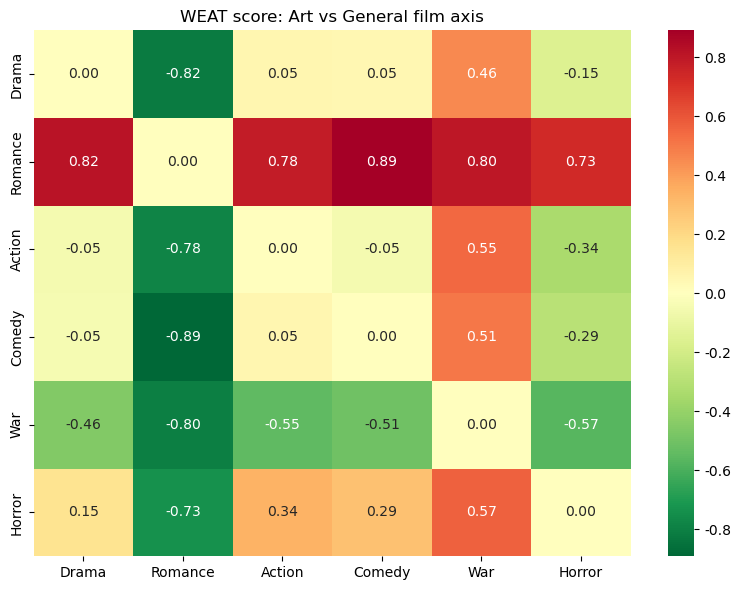

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

genre_name_en = ['Drama', 'Romance', 'Action', 'Comedy', 'War', 'Horror']

plt.rcParams['axes.unicode_minus'] = False

# 아래쪽 삼각형을 대칭으로 채우기 (위쪽만 계산했으니 대칭 위치는 부호 반대)
for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i > j:
            matrix[i][j] = -matrix[j][i]

plt.figure(figsize=(8,6))
ax = sns.heatmap(matrix, xticklabels=genre_name_en, yticklabels=genre_name_en,
                 annot=True, fmt='.2f', cmap='RdYlGn_r', center=0)
plt.title('WEAT score: Art vs General film axis')
plt.tight_layout()
plt.show()

In [32]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt',
             'synopsis_etc.txt', 'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt',
             'synopsis_musical.txt', 'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
             'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt',
             'synopsis_action.txt', 'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt',
             'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스',
              '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)', '성인물(에로)', '스릴러',
              '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']
genre_name_en = ['SF', 'Family', 'Show', 'Horror', 'Etc', 'Documentary', 'Drama', 'Romance',
                 'Musical', 'Mystery', 'Crime', 'Historical', 'Western', 'Adult', 'Thriller',
                 'Animation', 'Action', 'Adventure', 'War', 'Comedy', 'Fantasy']
print(len(genre_txt), "개 장르")

21 개 장르


In [33]:
# 21개 파일
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))
print("추출 완료")

synopsis_SF.txt 읽는 중...
synopsis_family.txt 읽는 중...
synopsis_show.txt 읽는 중...
synopsis_horror.txt 읽는 중...
synopsis_etc.txt 읽는 중...
synopsis_documentary.txt 읽는 중...
synopsis_drama.txt 읽는 중...
synopsis_romance.txt 읽는 중...
synopsis_musical.txt 읽는 중...
synopsis_mystery.txt 읽는 중...
synopsis_crime.txt 읽는 중...
synopsis_historical.txt 읽는 중...
synopsis_western.txt 읽는 중...
synopsis_adult.txt 읽는 중...
synopsis_thriller.txt 읽는 중...
synopsis_animation.txt 읽는 중...
synopsis_action.txt 읽는 중...
synopsis_adventure.txt 읽는 중...
synopsis_war.txt 읽는 중...
synopsis_comedy.txt 읽는 중...
synopsis_fantasy.txt 읽는 중...
추출 완료


In [34]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

m = [X[i].tocoo() for i in range(X.shape[0])]
w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]
for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)

attributes = []
for i in range(len(w)):
    attr = []
    j = 0
    while len(attr) < 15:
        word = vectorizer.get_feature_names_out()[w[i][j][0]]
        if word in model.wv:
            attr.append(word)
        j += 1
    attributes.append(attr)
print("장르별 단어셋 완료:", len(attributes), "개")

장르별 단어셋 완료: 21 개


In [35]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)
print("WEAT 계산 완료!")

WEAT 계산 완료!


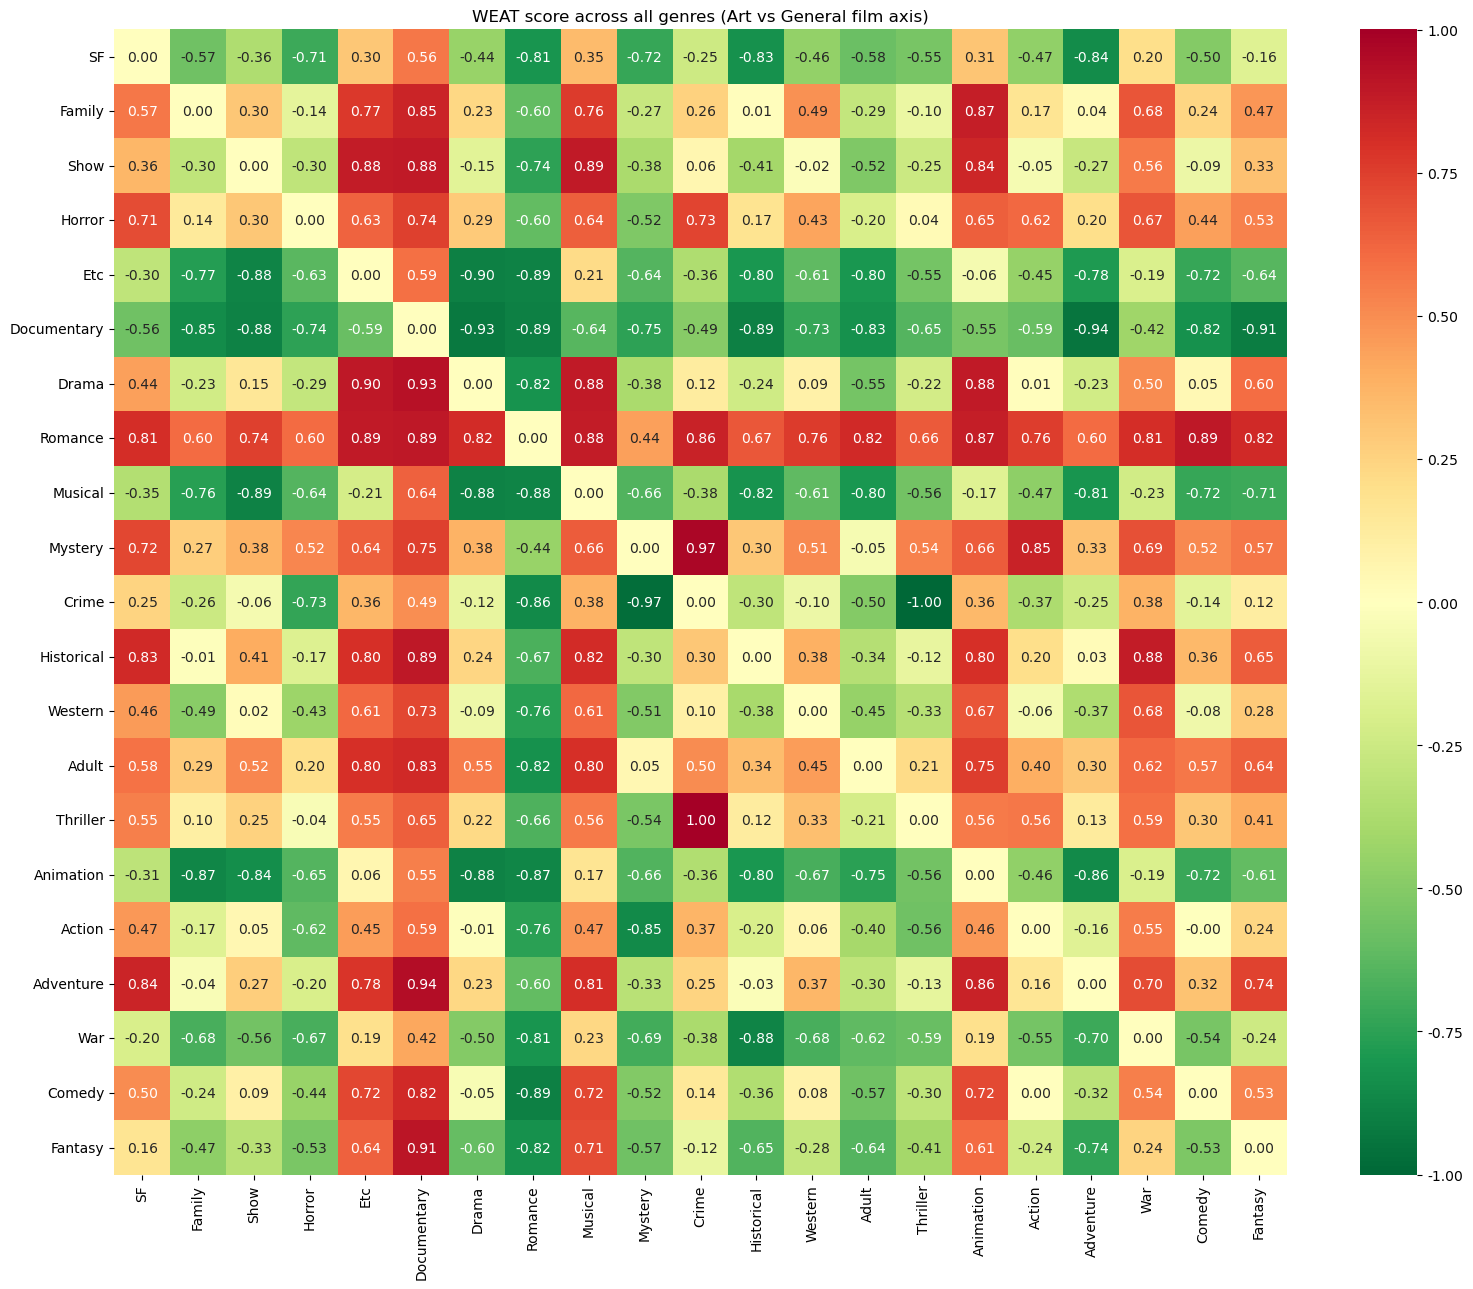

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i > j:
            matrix[i][j] = -matrix[j][i]

plt.figure(figsize=(16,13))
ax = sns.heatmap(matrix, xticklabels=genre_name_en, yticklabels=genre_name_en,
                 annot=True, fmt='.2f', cmap='RdYlGn_r', center=0)
plt.title('WEAT score across all genres (Art vs General film axis)')
plt.tight_layout()
plt.show()

워드임베딩 모델에 편향이 있는지를 WEAT로 측정하는 프로젝트를 했다.
WEAT는 결국 단어들이 어느 쪽 자석(유쾌/불쾌, 남성/여성 같은)에 더 가까운지를 숫자로 재는 도구
코사인 유사도로 가까움을 재고, 그게 그룹 전체로 커지면 WEAT score가 됐다.
직접 구글 모델로 재보니 과학=남성, 예술=여성 편향이 1.262로 나왔다. 
AI가 객관적일 거라 생각했는데, 학습한 데이터에 사람의 편견이 들어있으면 모델도 그걸 배운다는 걸 숫자로 보니 인상적이었다.
영화 시놉시스로 내 Word2Vec도 직접 만들었다. 
영화와 비슷한 단어로 작품·드라마·코미디가 나와서 잘 학습된 걸 확인했다. 
TF-IDF로 장르별 대표 단어를 뽑고, 전체 장르 heatmap까지 그렸다. 
멜로로맨스는 예술영화 쪽, 전쟁은 일반영화 쪽으로 쏠리는 게 보였다.

막혔던 점: 코랩에서 scipy 버전 충돌, 모델 파일 경로, 한글 폰트 문제로 계속 에러가 났다. 
에러 메시지를 읽으면서 원인을 찾아 해결했다. 
빨간 글씨가 다 실패는 아니라는 것(Successfully installed면 성공)도 새롭게 배웠다.

아쉬운 점: TF-IDF로 단어셋을 뽑아도 '자신·시작·위해'처럼 흔한 단어가 여러 장르에 끼어서, 장르 색깔이 또렷하지 않았다. 
비슷한 장르끼리는 점수가 ±1.0으로 튀기도 했다. 
공통 단어를 더 걸러내면 결과가 안정적일 것 같다.

/home/jovyan
MyWord2Vec.ipynb
